# Quater plane
This notebook cover examples using the quater plane.

# The mapping
The quater plane is mapped to the half plane using
\begin{equation*}
    z = \chi^2
\end{equation*}
with the inverse
\begin{equation*}
    \chi = \sqrt{z}
\end{equation*}

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from conformal_mappings.mappings import z_to_xi_quarter_plane, xi_to_z_quarter_plane
from conformal_mappings.elements import omega_uni_flow
from conformal_mappings.plotter import contour_flow_net

## Uniform flow in the quater plane
We consider a uniform flow that is parallell to both the positive $y$.axis and the positive $x$-axis.

In [43]:
# Varialbes
w = 1 + 0j

# Omega function
omega_func = lambda z: omega_uni_flow(z, w)

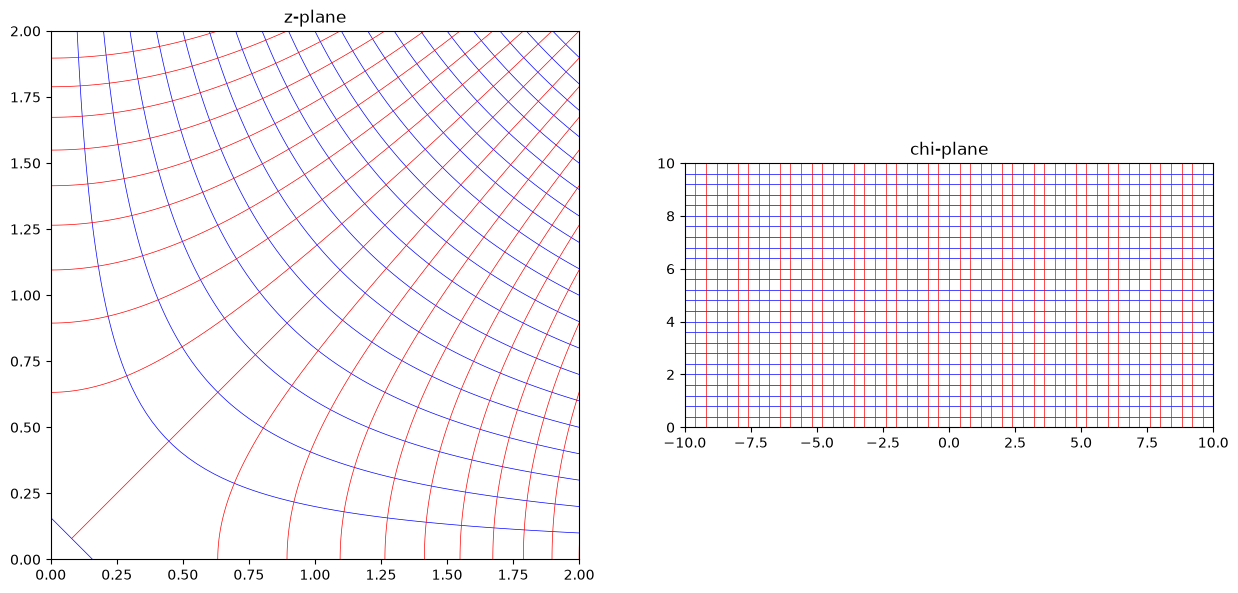

In [44]:
fig, ax = plt.subplots(1,2,figsize=(15, 7))
contour_flow_net(
    (-10, 10),
    (0, 10),
    flow_func= omega_func,
    levels=50,
    xgrid_points=400,
    ygrid_points=400,
    mapping_func=lambda chi: xi_to_z_quarter_plane(chi),
    ax=ax[0]
)
ax[0].set_xlim(0, 2)
ax[0].set_ylim(0, 2)
ax[0].set_title("z-plane")
ax[0].set_aspect('equal')

contour_flow_net(
    (-10,10),
    (0, 10),
    flow_func= omega_func,
    levels=50,
    xgrid_points=400,
    ygrid_points=400,
    mapping_func=None,
    ax=ax[1]
)
ax[1].set_xlim(-10, 10)
ax[1].set_ylim(0, 10)
ax[1].set_title("chi-plane")
ax[1].set_aspect('equal')

## A well near a coast
We consider the case of a well near a coast where we use the method of images to model the coast.

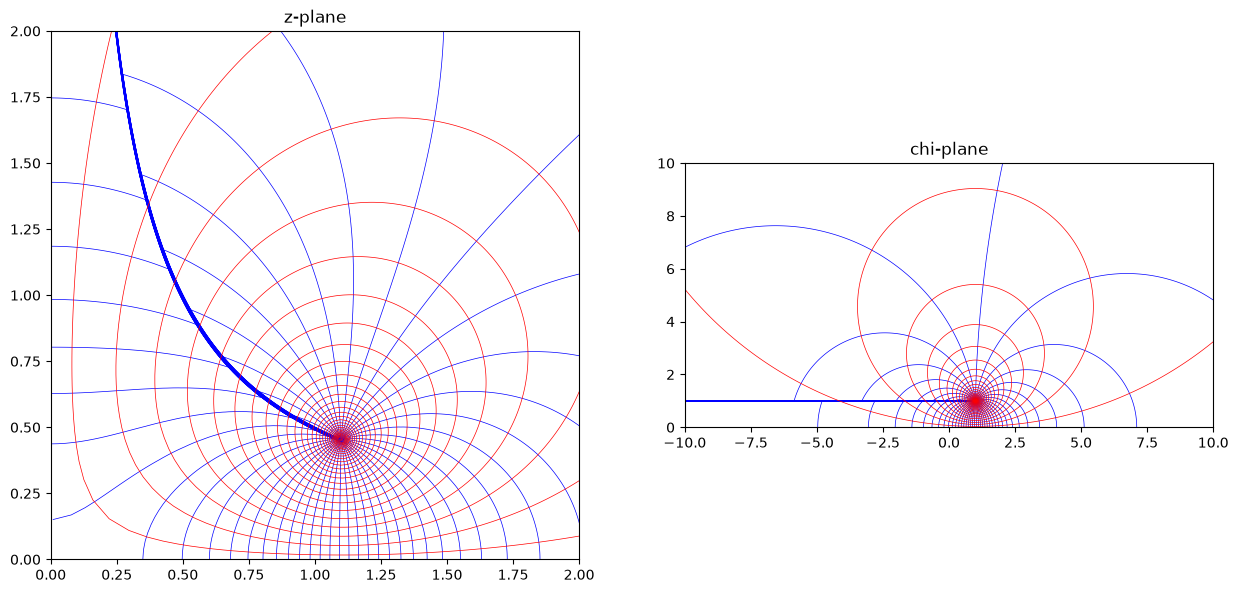

In [45]:
# Varialbes
from conformal_mappings.elements import omega_well


q = 1
zw = 1 + 1j

# Omega function
omega_func = lambda z: omega_well(z, q, lambda z: z-zw) - omega_well(z, q, lambda z: z-np.conj(zw))

fig, ax = plt.subplots(1,2,figsize=(15, 7))
contour_flow_net(
    (-10, 10),
    (0, 10),
    flow_func= omega_func,
    levels=50,
    xgrid_points=400,
    ygrid_points=400,
    mapping_func=lambda chi: xi_to_z_quarter_plane(chi),
    ax=ax[0]
)
ax[0].set_xlim(0, 2)
ax[0].set_ylim(0, 2)
ax[0].set_title("z-plane")
ax[0].set_aspect('equal')

contour_flow_net(
    (-10,10),
    (0, 10),
    flow_func= omega_func,
    levels=50,
    xgrid_points=400,
    ygrid_points=400,
    mapping_func=None,
    ax=ax[1]
)
ax[1].set_xlim(-10, 10)
ax[1].set_ylim(0, 10)
ax[1].set_title("chi-plane")
ax[1].set_aspect('equal')

We can also model the coast as a smooth curved boundary by moving the coast line in the $\chi$-plane.

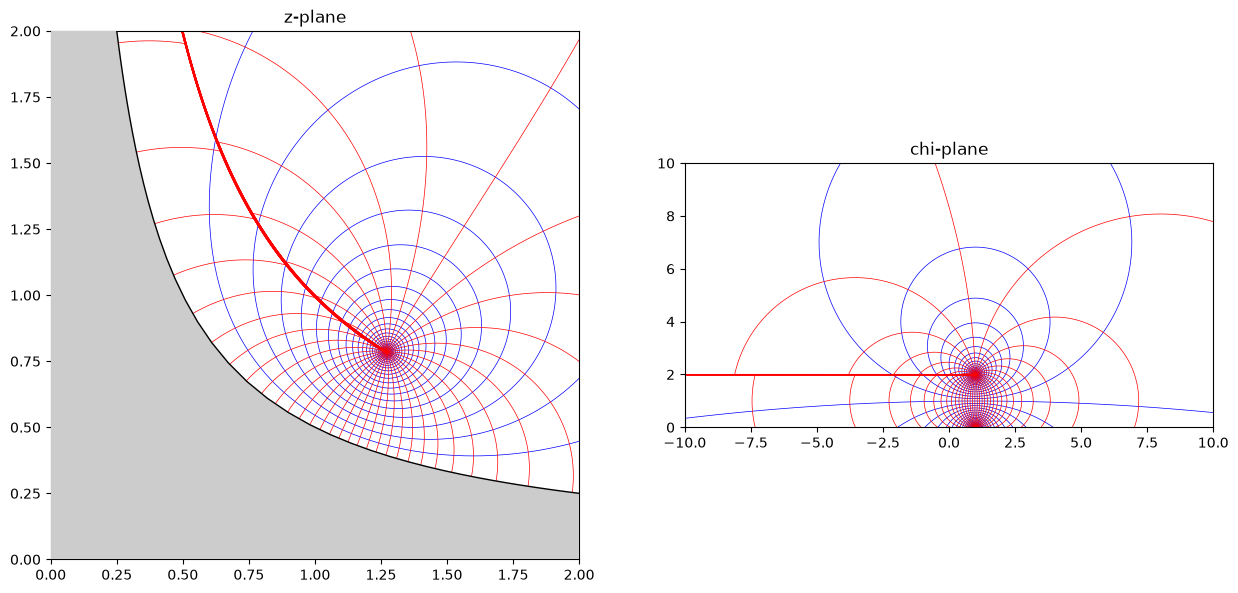

In [ ]:
zw = 1 + 2j

# Omega function
omega_func = lambda z: omega_well(z, q, lambda z: z-zw) - omega_well(z, q, lambda z: z-(np.conj(zw)+2j))

fig, ax = plt.subplots(1,2,figsize=(15, 7))
contour_flow_net(
    (-10, 10),
    (0, 10),
    flow_func= omega_func,
    levels=50,
    xgrid_points=400,
    ygrid_points=400,
    mapping_func=lambda chi: xi_to_z_quarter_plane(chi),
    ax=ax[0]
)
z = xi_to_z_quarter_plane(np.linspace(-40, 40, 400)+1j)
z[0] = -1 + z[0].imag*1j
ax[0].fill_between(z.real, z.imag, y2=-1, facecolor=(.8,.8,.8,1), edgecolor="k", zorder=10)
ax[0].set_xlim(0, 2)
ax[0].set_ylim(0, 2)
ax[0].set_title("z-plane")
ax[0].set_aspect('equal')

contour_flow_net(
    (-10,10),
    (0, 10),
    flow_func= omega_func,
    levels=50,
    xgrid_points=400,
    ygrid_points=400,
    mapping_func=None,
    ax=ax[1]
)
ax[1].set_xlim(-10, 10)
ax[1].set_ylim(0, 10)
ax[1].set_title("chi-plane")
ax[1].set_aspect('equal')